# Phase II: Cyanobacteria Abundance Forecasting

*Course project of **STATS 402: Interdisciplinary Data Analysis**.*

**Name:** Ziyue Yin

**NetID:** zy166

**How to use this Notebook *wisely*?**

## Prerequisites

Before we continue, please make sure that the following files exist in the corresponding path:
- ILW：`/dkucc/home/zy166/HAB-forecasting/datasets/processed/lake_ci_daily.parquet`
- Daymet：`/dkucc/home/zy166/HAB-forecasting/datasets/Daymet/daymet_glakes_daily.parquet`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 120

ROOT = Path("/dkucc/home/zy166/HAB-forecasting")

P_ILW    = ROOT / "datasets/processed/lake_ci_daily.parquet"
P_DAYMET = ROOT / "datasets/Daymet/daymet_glakes_daily.parquet"

print(P_ILW)
print(P_DAYMET)

/dkucc/home/zy166/HAB-forecasting/datasets/processed/lake_ci_daily.parquet
/dkucc/home/zy166/HAB-forecasting/datasets/Daymet/daymet_glakes_daily.parquet


Now, we read and merge the preprocessed ILW and Daymet data.

In [2]:
# 读取 ILW 和 Daymet
df_ilw = pd.read_parquet(P_ILW)
df_daymet = pd.read_parquet(P_DAYMET)

# 确保日期是 datetime
df_ilw["date"] = pd.to_datetime(df_ilw["date"])
df_daymet["date"] = pd.to_datetime(df_daymet["date"])

print("ILW columns:", df_ilw.columns.tolist())
print("Daymet columns:", df_daymet.columns.tolist())
print("ILW head:")
display(df_ilw.head())
print("Daymet head:")
display(df_daymet.head())

ILW columns: ['lake_id', 'date', 'product', 'CI_mean', 'CI_p90', 'n_valid', 'src', 'engine']
Daymet columns: ['lake_id', 'lake_name', 'date', 'tmin', 'tmax', 'prcp', 'srad', 'vp', 'dayl']
ILW head:


,lake_id,date,product,CI_mean,CI_p90,n_valid,src,engine
0,GL-1,2024-01-01 13:52:31+00:00,daily,0.000050,0.00005,4140,S3M_OLCI_EFRNT.20240101.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
1,GL-1,2024-01-02 13:36:49+00:00,daily,0.000052,0.00005,763,S3M_OLCI_EFRNT.20240102.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
2,GL-1,2024-01-03 14:02:06+00:00,daily,NaN,NaN,0,S3M_OLCI_EFRNT.20240103.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
3,GL-1,2024-01-04 13:40:26+00:00,daily,0.000052,0.00005,24332,S3M_OLCI_EFRNT.20240104.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
4,GL-1,2024-01-05 13:48:41+00:00,daily,0.000095,0.00005,887,S3M_OLCI_EFRNT.20240105.L3m.DAY.ILW_CONUS.V5.a...,netcdf4


Daymet head:


,lake_id,lake_name,date,tmin,tmax,prcp,srad,vp,dayl
0,GL-1,Erie,2024-01-01 12:00:00,-0.203859,2.958577,0.365888,102.113113,602.591919,32349.982422
1,GL-1,Erie,2024-01-02 12:00:00,-0.614141,2.104940,0.032669,89.671196,584.490723,32394.982422
2,GL-1,Erie,2024-01-03 12:00:00,0.070455,2.292327,1.025123,72.518929,613.914124,32443.656250
3,GL-1,Erie,2024-01-04 12:00:00,-3.859408,0.760503,0.000000,146.215637,460.223694,32495.972656
4,GL-1,Erie,2024-01-05 12:00:00,-4.978480,0.059113,0.000000,156.474442,422.685303,32551.880859


In [3]:
# 统一日期列：去时区 + 只保留日期（设为当天 00:00）
df_ilw["date"] = pd.to_datetime(df_ilw["date"]).dt.tz_localize(None).dt.normalize()
df_daymet["date"] = pd.to_datetime(df_daymet["date"]).dt.tz_localize(None).dt.normalize()

print(df_ilw["date"].dtype, df_daymet["date"].dtype)
print(df_ilw["date"].head())
print(df_daymet["date"].head())

datetime64[ns] datetime64[ns]
0   2024-01-01
1   2024-01-02
2   2024-01-03
3   2024-01-04
4   2024-01-05
Name: date, dtype: datetime64[ns]
0   2024-01-01
1   2024-01-02
2   2024-01-03
3   2024-01-04
4   2024-01-05
Name: date, dtype: datetime64[ns]


In [4]:
# 只保留 ILW 中有有效像元的观测
df_ilw = df_ilw.copy()
df_ilw = df_ilw[df_ilw["n_valid"].fillna(0) > 0]

# 有 product 列的话，也可以只选 daily
if "product" in df_ilw.columns:
    df_ilw = df_ilw[df_ilw["product"] == "daily"]

# 合并成一个 panel：lake_id × date
df = (
    df_ilw.merge(
        df_daymet,
        on=["lake_id", "date"],
        how="inner",
        suffixes=("_ilw", "_daymet"),
    )
)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (1698, 15)


,lake_id,date,product,CI_mean,CI_p90,n_valid,src,engine,lake_name,tmin,tmax,prcp,srad,vp,dayl
0,GL-1,2024-01-01,daily,0.000050,0.00005,4140,S3M_OLCI_EFRNT.20240101.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-0.203859,2.958577,0.365888,102.113113,602.591919,32349.982422
1,GL-1,2024-01-02,daily,0.000052,0.00005,763,S3M_OLCI_EFRNT.20240102.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-0.614141,2.104940,0.032669,89.671196,584.490723,32394.982422
2,GL-1,2024-01-04,daily,0.000052,0.00005,24332,S3M_OLCI_EFRNT.20240104.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-3.859408,0.760503,0.000000,146.215637,460.223694,32495.972656
3,GL-1,2024-01-05,daily,0.000095,0.00005,887,S3M_OLCI_EFRNT.20240105.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-4.978480,0.059113,0.000000,156.474442,422.685303,32551.880859
4,GL-1,2024-01-06,daily,0.000050,0.00005,7,S3M_OLCI_EFRNT.20240106.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-3.090726,2.353635,2.988052,148.110809,486.841797,32611.357422


特征工程（历史 & 滚动 + 季节性）

这里我们构造「条件在所有历史」的压缩表示：

CI_p90 的 lag1、lag7、lag28；roll7、roll28；

Daymet 的 roll7、roll28；

季节性（sin/cos(doy)）。

In [5]:
target_col = "CI_p90"

daymet_vars  = ["tmin", "tmax", "prcp", "srad", "vp", "dayl"]

In [6]:
# 从合并后的 df 开始
df_feat = df.copy()
df_feat["date"] = pd.to_datetime(df_feat["date"])
df_feat = df_feat.sort_values(["lake_id", "date"]).reset_index(drop=True)

# ====== 基础派生变量 ======
df_feat["doy"] = df_feat["date"].dt.dayofyear
df_feat["sin_doy"] = np.sin(2 * np.pi * df_feat["doy"] / 365.25)
df_feat["cos_doy"] = np.cos(2 * np.pi * df_feat["doy"] / 365.25)

# 日平均温度
df_feat["tmean"] = (df_feat["tmin"] + df_feat["tmax"]) / 2

group = df_feat.groupby("lake_id", group_keys=False)

# ====== 1. CI / ILW 的“从年初到 t” expanding 特征 ======
# 这些真正实现了：t 的特征使用 2024-01-01 ~ t 的全部历史
for col in ["CI_p90", "CI_mean"]:
    # 从年初到 t 的累计均值
    df_feat[f"{col}_exp_mean"] = (
        group[col]
        .expanding(min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    # 累计标准差（从至少 2 个样本开始）
    df_feat[f"{col}_exp_std"] = (
        group[col]
        .expanding(min_periods=2)
        .std()
        .reset_index(level=0, drop=True)
    )
    # 累计最大值（历史峰值强度）
    df_feat[f"{col}_exp_max"] = (
        group[col]
        .expanding(min_periods=1)
        .max()
        .reset_index(level=0, drop=True)
    )

# ====== 2. Daymet 的“从年初到 t” expanding 特征（可视为慢气候背景） ======
for var in ["tmean", "prcp", "srad", "vp"]:
    df_feat[f"{var}_exp_mean"] = (
        group[var]
        .expanding(min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

# ====== 3. 短期记忆：lag + rolling（仍然保留） ======
# CI_p90 的 lag（用到 t-1, t-7, t-28）
for lag in [1, 7, 28]:
    df_feat[f"CI_p90_lag{lag}"] = group["CI_p90"].shift(lag)

# CI_p90 的 rolling 均值（最近 7/28 天）
for w in [7, 28]:
    df_feat[f"CI_p90_roll{w}"] = (
        group["CI_p90"]
        .rolling(window=w, min_periods=max(3, w // 4))
        .mean()
        .reset_index(level=0, drop=True)
    )

# Daymet 的 rolling 均值（短期天气背景）
for var in ["tmin", "tmax", "prcp", "srad", "vp", "dayl", "tmean"]:
    for w in [7, 28]:
        df_feat[f"{var}_roll{w}"] = (
            group[var]
            .rolling(window=w, min_periods=max(3, w // 4))
            .mean()
            .reset_index(level=0, drop=True)
        )

print("df_feat shape after feature engineering:", df_feat.shape)
df_feat.head()

df_feat shape after feature engineering: (1698, 48)


,lake_id,date,product,CI_mean,CI_p90,n_valid,src,engine,lake_name,tmin,...,prcp_roll7,prcp_roll28,srad_roll7,srad_roll28,vp_roll7,vp_roll28,dayl_roll7,dayl_roll28,tmean_roll7,tmean_roll28
0,GL-1,2024-01-01,daily,0.000050,0.00005,4140,S3M_OLCI_EFRNT.20240101.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-0.203859,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL-1,2024-01-02,daily,0.000052,0.00005,763,S3M_OLCI_EFRNT.20240102.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-0.614141,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GL-1,2024-01-04,daily,0.000052,0.00005,24332,S3M_OLCI_EFRNT.20240104.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-3.859408,...,0.132852,NaN,112.666649,NaN,549.102112,NaN,32413.645833,NaN,0.191102,NaN
3,GL-1,2024-01-05,daily,0.000095,0.00005,887,S3M_OLCI_EFRNT.20240105.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-4.978480,...,0.099639,NaN,123.618597,NaN,517.497910,NaN,32448.204590,NaN,-0.471594,NaN
4,GL-1,2024-01-06,daily,0.000050,0.00005,7,S3M_OLCI_EFRNT.20240106.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-3.090726,...,0.677322,NaN,128.517039,NaN,511.366687,NaN,32480.835156,NaN,-0.450984,NaN


构造多步预测 target（t+1, t+7, t+28）

In [7]:
HORIZONS = [1, 7, 28]

for h in HORIZONS:
    col_name = f"y_h{h}"
    df_feat[col_name] = (
        group[target_col]
        .shift(-h)              # CI_p90(t+h)
        .pipe(np.log1p)         # log1p
    )

target_cols = [f"y_h{h}" for h in HORIZONS]

# 去掉任意 target 缺失的行（意味着靠近年尾）
df_feat = df_feat.dropna(subset=target_cols).copy()

print("Shape after adding multi-horizon targets:", df_feat.shape)
df_feat[target_cols + ["lake_id", "date"]].head()

Shape after adding multi-horizon targets: (1558, 51)


,y_h1,y_h7,y_h28,lake_id,date
0,0.00005,0.000050,0.00005,GL-1,2024-01-01
1,0.00005,0.002155,0.00005,GL-1,2024-01-02
2,0.00005,0.000050,0.00005,GL-1,2024-01-04
3,0.00005,0.000055,0.00005,GL-1,2024-01-05
4,0.00005,0.000050,0.00005,GL-1,2024-01-06


确定特征列 & 工具函数

In [8]:
non_feature_cols = set(
    ["lake_id", "date", target_col, "doy"] + target_cols
)

# 只用数值列做特征（兼容 pandas 的 Int64Dtype、Float64Dtype 等）
feature_cols = [
    c for c in df_feat.columns
    if c not in non_feature_cols and is_numeric_dtype(df_feat[c].dtype)
]

print("Number of features:", len(feature_cols))
print("Some features:", feature_cols[:10])

# 看一下哪些列还有 NaN
nan_counts = df_feat[feature_cols + target_cols].isna().sum()
print("NaN counts (before drop):")
print(nan_counts[nan_counts > 0])

# 丢掉任意 feature 或任意 target 为 NaN 的行
df_model = df_feat.dropna(subset=feature_cols + target_cols).copy()

print("Shape before drop:", df_feat.shape)
print("Shape after drop:", df_model.shape)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def build_models(random_state=42):
    """
    返回一个 {name: model} 字典，每个 model 都支持多输出 (3 个 horizon)。
    这里的“ARIMAX 风格”是通过 lag + exogenous 特征 + Ridge/Lasso 来实现的全局 ARX 模型。
    """
    models = {}

    # ========= 1) Random Forest =========
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=3,
        random_state=random_state,
        n_jobs=-1,
    )
    models["RF"] = MultiOutputRegressor(rf)

    # ========= 2) Gradient Boosting =========
    gb = GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=random_state,
    )
    models["GBR"] = MultiOutputRegressor(gb)

    # ========= 3) MLP（和你原来一样） =========
    mlp = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            max_iter=500,
            random_state=random_state,
        ),
    )
    models["MLP"] = MultiOutputRegressor(mlp)

    # ========= 4) Ridge Regression（全局线性回归） =========
    # 直接用你现有的所有特征（包括 CI 的 lag 与 Daymet），
    # 可以看作“全局线性 ARX”，等价于一个线性 ARIMAX。
    ridge = Ridge(
        alpha=1.0,
        random_state=random_state,
    )
    models["Ridge"] = MultiOutputRegressor(ridge)

    # ========= 5) XGBoost =========
    # 如果环境里没装 xgboost，就跳过并打印一行信息。
    try:
        from xgboost import XGBRegressor

        xgb = XGBRegressor(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=random_state,
        )
        models["XGB"] = MultiOutputRegressor(xgb)
    except ImportError:
        print("[INFO] xgboost is not installed; skipping XGB model.")

    return models

def compute_metrics_per_horizon(y_true, y_pred, horizons):
    """返回 {h: {'rmse':..., 'r2':...}}"""
    metrics = {}
    for j, h in enumerate(horizons):
        yt = y_true[:, j]
        yp = y_pred[:, j]
        metrics[h] = {
            "rmse": rmse(yt, yp),
            "r2": r2_score(yt, yp),
        }
    return metrics

Number of features: 40
Some features: ['CI_mean', 'n_valid', 'tmin', 'tmax', 'prcp', 'srad', 'vp', 'dayl', 'sin_doy', 'cos_doy']
NaN counts (before drop):
CI_p90_exp_std       5
CI_mean_exp_std      5
CI_p90_lag1          5
CI_p90_lag7         35
CI_p90_lag28       140
CI_p90_roll7        10
CI_p90_roll28       30
tmin_roll7          10
tmin_roll28         30
tmax_roll7          10
tmax_roll28         30
prcp_roll7          10
prcp_roll28         30
srad_roll7          10
srad_roll28         30
vp_roll7            10
vp_roll28           30
dayl_roll7          10
dayl_roll28         30
tmean_roll7         10
tmean_roll28        30
dtype: int64
Shape before drop: (1558, 51)
Shape after drop: (1418, 51)


LOLO（4 湖训练 → 1 湖预测）的整体评估

In [9]:
rows = []

all_lakes = sorted(df_model["lake_id"].unique())
print("Lakes:", all_lakes)

for holdout in all_lakes:
    print(f"\n=== Holdout lake: {holdout} ===")
    train_df = df_model[df_model["lake_id"] != holdout].copy()
    test_df  = df_model[df_model["lake_id"] == holdout].copy()

    X_train = train_df[feature_cols].values
    y_train = train_df[target_cols].values
    X_test  = test_df[feature_cols].values
    y_test  = test_df[target_cols].values

    # ------------ baselines ------------
    # # 1) climatology: 训练集 target 的均值
    # mean_vec = y_train.mean(axis=0)  # shape (3,)
    # y_pred_clim = np.tile(mean_vec, (len(y_test), 1))
    # metrics_clim = compute_metrics_per_horizon(y_test, y_pred_clim, HORIZONS)
    # for h in HORIZONS:
    #     rows.append({
    #         "holdout_lake": holdout,
    #         "model": "Baseline_climatology",
    #         "horizon": h,
    #         "rmse": metrics_clim[h]["rmse"],
    #         "r2": metrics_clim[h]["r2"],
    #     })

    # # 2) persistence: 用当前 log1p(CI_p90(t)) 作为所有 horizon 的预测
    # ci_log = np.log1p(test_df[target_col].values)
    # y_pred_pers = np.tile(ci_log[:, None], (1, len(HORIZONS)))
    # metrics_pers = compute_metrics_per_horizon(y_test, y_pred_pers, HORIZONS)
    # for h in HORIZONS:
    #     rows.append({
    #         "holdout_lake": holdout,
    #         "model": "Baseline_persistence",
    #         "horizon": h,
    #         "rmse": metrics_pers[h]["rmse"],
    #         "r2": metrics_pers[h]["r2"],
    #     })

    # ------------ fancy models ------------
    base_models = build_models(random_state=42)

    for name, model in base_models.items():
        print(f"  Training {name} ...")
        m = clone(model)
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
        metrics = compute_metrics_per_horizon(y_test, y_pred, HORIZONS)
        for h in HORIZONS:
            rows.append({
                "holdout_lake": holdout,
                "model": name,
                "horizon": h,
                "rmse": metrics[h]["rmse"],
                "r2": metrics[h]["r2"],
            })

# 汇总结果
results_lolo = pd.DataFrame(rows)
results_lolo

Lakes: ['GL-1', 'GL-2', 'GL-3', 'GL-4', 'GL-5']

=== Holdout lake: GL-1 ===
  Training RF ...
  Training GBR ...
  Training MLP ...
  Training Ridge ...
  Training XGB ...

=== Holdout lake: GL-2 ===
  Training RF ...
  Training GBR ...
  Training MLP ...
  Training Ridge ...
  Training XGB ...

=== Holdout lake: GL-3 ===
  Training RF ...
  Training GBR ...
  Training MLP ...
  Training Ridge ...
  Training XGB ...

=== Holdout lake: GL-4 ===
  Training RF ...
  Training GBR ...
  Training MLP ...
  Training Ridge ...
  Training XGB ...

=== Holdout lake: GL-5 ===
  Training RF ...
  Training GBR ...
  Training MLP ...
  Training Ridge ...
  Training XGB ...


,holdout_lake,model,horizon,rmse,r2
0,GL-1,RF,1,0.001513,0.030300
1,GL-1,RF,7,0.001532,0.004787
2,GL-1,RF,28,0.001501,0.045473
3,GL-1,GBR,1,0.001614,-0.104048
4,GL-1,GBR,7,0.001561,-0.033148
...,...,...,...,...,...
70,GL-5,Ridge,7,0.000444,-6.020596
71,GL-5,Ridge,28,0.000434,-5.692836
72,GL-5,XGB,1,0.000348,-3.318064
73,GL-5,XGB,7,0.000257,-1.357739


pivot 一下看看每个湖 / 每个 horizon / 每个模型的表现。

In [10]:
results_pivot = (
    results_lolo
    .pivot_table(index=["holdout_lake", "model"],
                 columns="horizon",
                 values="rmse")
)
results_pivot

horizon                   1         7         28
holdout_lake model                              
GL-1         GBR    0.001614  0.001561  0.001529
             MLP    0.595353  0.593549  0.594498
             RF     0.001513  0.001532  0.001501
             Ridge  0.001577  0.001576  0.001578
             XGB    0.001602  0.001575  0.001536
GL-2         GBR    0.000421  0.000446  0.000525
             MLP    0.062033  0.062055  0.061996
             RF     0.000432  0.000415  0.000432
             Ridge  0.000420  0.000421  0.000436
             XGB    0.000412  0.000453  0.000417
GL-3         GBR    0.002788  0.000734  0.000685
             MLP    0.089308  0.089253  0.089090
             RF     0.000635  0.000749  0.000452
             Ridge  0.000430  0.000448  0.000633
             XGB    0.000988  0.000835  0.000478
GL-4         GBR    0.000493  0.000387  0.000559
             MLP    0.077027  0.077364  0.076977
             RF     0.000509  0.000570  0.000536
             Ridge  0.000633  0.000641  0.000627
             XGB    0.000492  0.000564  0.000615
GL-5         GBR    0.001780  0.000600  0.000418
             MLP    0.066465  0.066537  0.066664
             RF     0.000453  0.000342  0.000310
             Ridge  0.000471  0.000444  0.000434
             XGB    0.000348  0.000257  0.000218

针对一个 holdout 湖训练模型（后面要用来交互预测）

假设我们想专门研究某个湖，比如 GL-5。

In [11]:
HOLDOUT_LAKE = "GL-1"

train_df = df_model[df_model["lake_id"] != HOLDOUT_LAKE].copy()
test_df  = df_model[df_model["lake_id"] == HOLDOUT_LAKE].copy()

X_train = train_df[feature_cols].values
y_train = train_df[target_cols].values
X_test  = test_df[feature_cols].values
y_test  = test_df[target_cols].values

models = build_models(random_state=42)

fitted_models = {}
for name, model in models.items():
    print(f"Training {name} for holdout {HOLDOUT_LAKE} ...")
    m = clone(model)
    m.fit(X_train, y_train)
    fitted_models[name] = m

print("Done.")

Training RF for holdout GL-1 ...
Training GBR for holdout GL-1 ...
Training MLP for holdout GL-1 ...
Training Ridge for holdout GL-1 ...
Training XGB for holdout GL-1 ...
Done.


给定一个具体日期 t，预测 t+1, t+7, t+28，并画「三点曲线」

这样你可以随便换 example_date，或者写成一个函数，输入日期字符串就能看三点 forecast。

Example date: 2024-08-07 00:00:00
True (log1p CI) for horizons [1,7,28]: [4.99987524e-05 4.49623611e-03 2.90083298e-03]
Pred (log1p CI): [0.00011724 0.00071435 0.00283421]


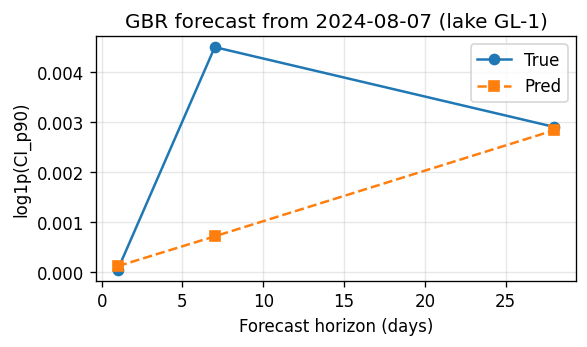

In [14]:
def predict_for_date(model, df_holdout, date, feature_cols, horizons, target_cols):
    """
    model: 已经在 4 湖上训练好的模型
    df_holdout: 该 holdout 湖的 df (含特征和 target)
    date: datetime 或 'YYYY-MM-DD'
    """
    date = pd.to_datetime(date)
    row = df_holdout[df_holdout["date"] == date]

    if row.empty:
        raise ValueError(f"No row found for date {date} in holdout lake.")

    # 要求这一天的三个 target 都存在（否则没法比较真值）
    if row[target_cols].isna().any(axis=None):
        raise ValueError(f"Targets for date {date} are NaN (likely too close to year end).")

    X = row[feature_cols].values
    y_true = row[target_cols].values[0]
    y_pred = model.predict(X)[0]

    return y_true, y_pred

def plot_horizon_curve(horizons, y_true, y_pred, title=""):
    plt.figure(figsize=(5, 3))
    plt.plot(horizons, y_true, marker="o", label="True")
    plt.plot(horizons, y_pred, marker="s", linestyle="--", label="Pred")
    plt.xlabel("Forecast horizon (days)")
    plt.ylabel("log1p(CI_p90)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 举个例子：在 GL-5 中选一个日期（确保不在最后28天，可以先 print(test_df['date'].tail()) 看看范围）
example_date = test_df["date"].iloc[170]
print("Example date:", example_date)

model_name = "GBR"   # "RF" 或 "GBR" / "MLP"
model = fitted_models[model_name]

y_true, y_pred = predict_for_date(
    model=model,
    df_holdout=test_df,
    date=example_date,
    feature_cols=feature_cols,
    horizons=HORIZONS,
    target_cols=target_cols,
)

print("True (log1p CI) for horizons [1,7,28]:", y_true)
print("Pred (log1p CI):", y_pred)

plot_horizon_curve(HORIZONS, y_true, y_pred,
                   title=f"{model_name} forecast from {example_date.date()} (lake {HOLDOUT_LAKE})")

在 holdout 湖上「滚动预测全年」并画时序

这里我们还是用真实历史特征（不做 auto-reg 更新），但在 test_df 的整条时间序列上滚动预测每个 t 的 t+h。

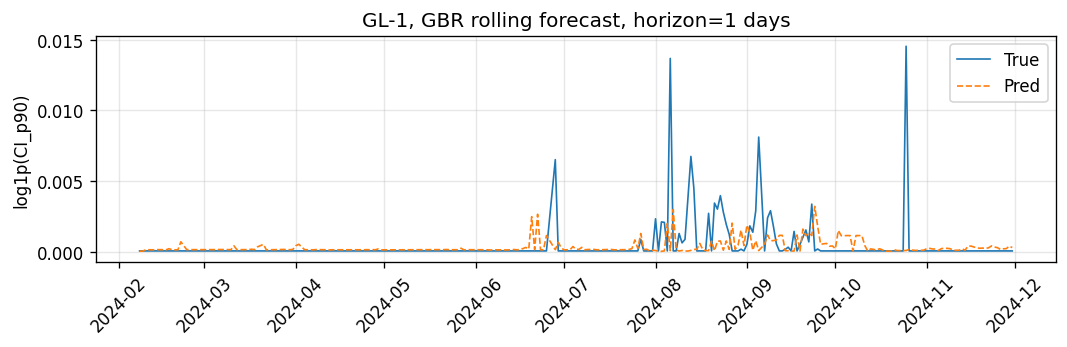

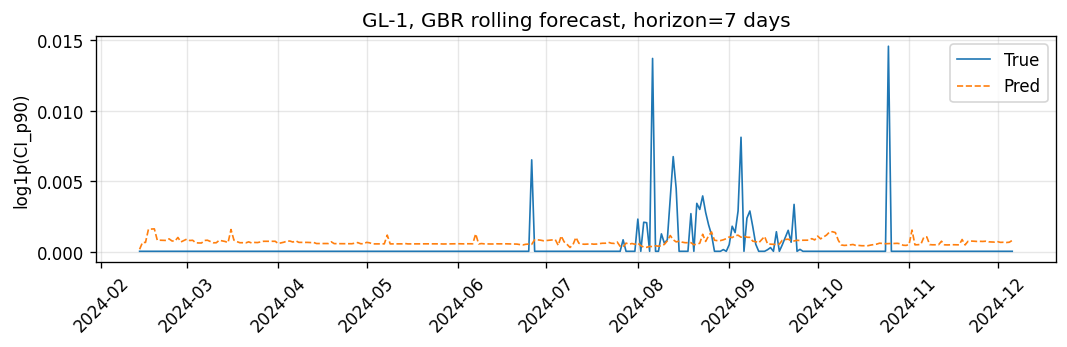

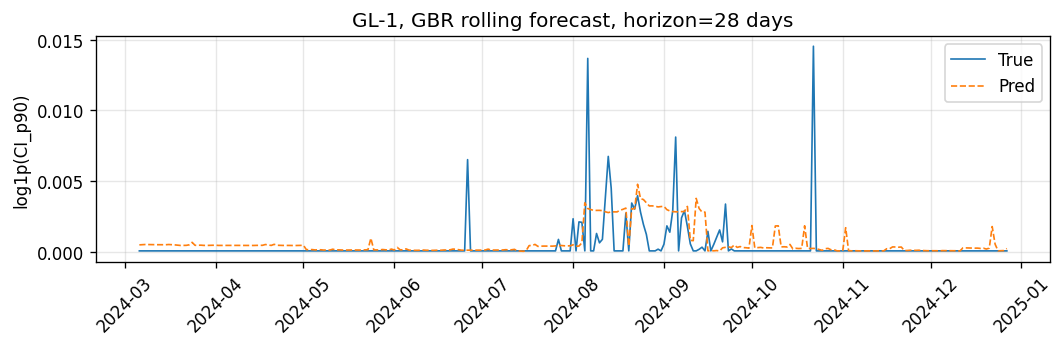

In [15]:
def rolling_forecast(model, df_holdout, feature_cols, horizons, target_cols):
    """
    对 holdout 湖的所有样本 t 做预测，返回一个 dict:
      {h: DataFrame(date_target, y_true, y_pred)}
    这里的 date_target = t + h 天，对应的是 CI_p90(t+h) 的时间。
    """
    X_all = df_holdout[feature_cols].values
    y_true_all = df_holdout[target_cols].values
    y_pred_all = model.predict(X_all)

    result = {}

    for j, h in enumerate(horizons):
        # 每个 t 对应的目标日期是 t+h
        dates_target = df_holdout["date"] + pd.to_timedelta(h, unit="D")
        df_h = pd.DataFrame({
            "date_target": dates_target,
            "y_true": y_true_all[:, j],
            "y_pred": y_pred_all[:, j],
        })
        # 某些 date_target 可能超出原始范围，但没关系，按时间画就行
        result[h] = df_h

    return result

def plot_forecast_timeseries(df_h, title=""):
    plt.figure(figsize=(9, 3))
    plt.plot(df_h["date_target"], df_h["y_true"], label="True", linewidth=1)
    plt.plot(df_h["date_target"], df_h["y_pred"], label="Pred", linewidth=1, linestyle="--")
    plt.ylabel("log1p(CI_p90)")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# model
model = fitted_models["GBR"]

rolling_results = rolling_forecast(
    model=model,
    df_holdout=test_df,
    feature_cols=feature_cols,
    horizons=HORIZONS,
    target_cols=target_cols,
)

for h in HORIZONS:
    df_h = rolling_results[h]
    # 只计算非 NaN 的 loss
    mask = df_h["y_true"].notna()
    r2_h = r2_score(df_h.loc[mask, "y_true"], df_h.loc[mask, "y_pred"])
    rmse_h = rmse(df_h.loc[mask, "y_true"], df_h.loc[mask, "y_pred"])
    # print(f"[Rolling] horizon={h}d, R2={r2_h:.3f}, RMSE={rmse_h:.3e}")

    plot_forecast_timeseries(
        df_h,
        title=f"{HOLDOUT_LAKE}, {model_name} rolling forecast, horizon={h} days",
    )